# Chile Workorders: Weekly Forecast — SARIMA + GLM ensemble
Same recipe as the ticket-forecast notebook, but **y = weekly count of tickets with `has_work_order == "Y"`** (week = Mon–Sun, tickets bucketed by `contact_create_dt`).

**Rules we're holding ourselves to (same as tickets notebook):**
1. Every forecast for week *W* is made by a model that has seen data only through the Sunday before week *W* — never refit or peeked using anything from week *W* onward.
2. Model/parameter **selection** (SARIMA order, GLM features, ensemble weights, which ensemble) uses only an older 25-week window (the **TUNE** set). The most recent 25 weeks (**HOLDOUT**) are only used to *report* a number — never used to pick anything.
3. If the tuned config doesn't reach the MAPE target on HOLDOUT, we report that honestly rather than re-tuning against it or cherry-picking weeks.

**MAPE target:** < 10% ideal, 12–13% acceptable.

### 1. Imports

In [3]:
import warnings, itertools
import numpy as np
import pandas as pd
import holidays
import matplotlib.pyplot as plt
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

### 2. Data — daily workorder tickets (has_work_order = Y)

In [4]:
DATA_PATH = "/Users/vaibhavi/Downloads/ticket_full.csv"    # <- apna path yahan daalo (e.g. /Users/vaibhavi/Downloads/ticket_full.csv)

df = pd.read_csv(DATA_PATH, usecols=["contact_create_dt", "has_work_order"], parse_dates=["contact_create_dt"])

# y: sirf woh tickets jinka has_work_order == "Y"
wo = df[df["has_work_order"] == "Y"]

daily = wo.groupby(wo["contact_create_dt"].dt.normalize()).size()
daily = daily.reindex(pd.date_range(daily.index.min(), daily.index.max()), fill_value=0)   # missing days = 0 workorders

print(f"{len(df):,} tickets total | {len(wo):,} with workorder ({len(wo)/len(df):.1%})")
print(f"{len(daily)} days | {daily.index.min().date()} to {daily.index.max().date()} | mean {daily.mean():.1f}/day | ~{daily.mean()*7:.0f}/week")

93,539 tickets total | 9,181 with workorder (9.8%)
613 days | 2024-12-26 to 2026-08-30 | mean 15.0/day | ~105/week


### 3. Helpers — MAPE, weekly actuals, walk-forward

In [5]:
def mape(actual, pred):
    actual, pred = np.asarray(actual, float), np.asarray(pred, float)
    return np.mean(np.abs(pred - actual) / actual) * 100      # har week ka |forecast − actual| ÷ actual, average, ×100

def weekly_actual(week_ends):
    return np.array([daily.loc[e - pd.Timedelta(days=6):e].sum() for e in week_ends])   # Mon-Sun sum = weekly workorders

def walk_forward(week_ends, forecast_fn):
    # har Sunday e ke liye: data sirf pichhle Sunday (e - 7 days) tak, agle 7 din ka forecast, sum = weekly forecast
    return np.array([forecast_fn(daily.loc[:e - pd.Timedelta(days=7)]).sum() for e in week_ends])

### 4. Model A — SARIMAX (on log1p of daily counts)

In [6]:
def sarimax_forecast(history, order, seasonal_order):
    model = SARIMAX(np.log1p(history), order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return np.expm1(model.forecast(7))

### 5. Model B — Poisson GLM (workorders/day = counts, so Poisson)

In [7]:
cl_holidays = holidays.Chile(years=range(2024, 2028))     # Chile public holidays

def is_holiday(dates):
    return np.array([int(d.date() in cl_holidays) for d in dates])

def make_features(s, trend=False, avg_long=28):
    X = pd.DataFrame(index=s.index)
    for d in range(7):
        X[f"dow{d}"] = (s.index.dayofweek == d).astype(int)            # weekday dummies
    X["holiday"]      = is_holiday(s.index)
    X["holiday_prev"] = is_holiday(s.index - pd.Timedelta(days=1))
    X["holiday_next"] = is_holiday(s.index + pd.Timedelta(days=1))

    last_sunday = s.index - pd.to_timedelta(s.index.dayofweek + 1, unit="D")   # sirf pichhle Sunday tak ka data use hoga
    X["log_avg7"]           = np.log(s.rolling(7).mean().reindex(last_sunday).values + 1)
    X[f"log_avg{avg_long}"] = np.log(s.rolling(avg_long).mean().reindex(last_sunday).values + 1)
    X["log_same_dow"]       = np.log(sum(s.shift(k) for k in (7, 14, 21, 28)) / 4 + 1)
    if trend:
        X["t"] = (last_sunday - s.index.min()).days / 365.0
    return X

def glm_forecast(history, **feature_kwargs):
    future = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=7)
    s = history.reindex(history.index.append(future))
    X = make_features(s, **feature_kwargs)
    train = X.loc[history.index].dropna()

    model = make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.01, max_iter=1000))
    model.fit(train, history.loc[train.index])
    return pd.Series(model.predict(X.loc[future]), index=future)

### 6. TUNE / HOLDOUT split
Workorders are only ~15/day (~100/week), so a single week is noisy (Poisson noise alone ≈ 9–10% of a week's count) — this is why the longer 56-day average is added as a GLM option below.

In [8]:
def last_weeks(n, skip=0):
    sundays = daily.index[daily.index.dayofweek == 6]
    return sundays[len(sundays) - skip - n : len(sundays) - skip]

TUNE_ENDS = last_weeks(25, skip=25)
HOLD_ENDS = last_weeks(25)

tune_actual = weekly_actual(TUNE_ENDS)
hold_actual = weekly_actual(HOLD_ENDS)

print("TUNE   :", TUNE_ENDS.min().date(), "to", TUNE_ENDS.max().date(), f"| avg {tune_actual.mean():.0f} workorders/week")
print("HOLDOUT:", HOLD_ENDS.min().date(), "to", HOLD_ENDS.max().date(), f"| avg {hold_actual.mean():.0f} workorders/week")

TUNE   : 2025-09-21 to 2026-03-08 | avg 81 workorders/week
HOLDOUT: 2026-03-15 to 2026-08-30 | avg 125 workorders/week


### 7. Tune SARIMAX — 20 settings, TUNE weeks only

In [9]:
orders          = [(1,0,1), (2,0,1), (1,1,1), (2,1,1), (0,1,1)]
seasonal_orders = [(1,1,1,7), (0,1,1,7), (1,1,0,7), (2,1,1,7)]

sarima_preds = {}
for order, sorder in itertools.product(orders, seasonal_orders):
    try:
        sarima_preds[(order, sorder)] = walk_forward(TUNE_ENDS, lambda h: sarimax_forecast(h, order, sorder))
    except Exception:
        pass

sarima_scores = {k: mape(tune_actual, p) for k, p in sarima_preds.items()}
best_sarima = min(sarima_scores, key=sarima_scores.get)

pd.DataFrame(sarima_scores.items(), columns=["(order, seasonal_order)", "tune_mape"]).sort_values("tune_mape").head(5)

,"(order, seasonal_order)",tune_mape
9,"((1, 1, 1), (0, 1, 1, 7))",16.571807
8,"((1, 1, 1), (1, 1, 1, 7))",16.592885
15,"((2, 1, 1), (2, 1, 1, 7))",16.601982
17,"((0, 1, 1), (0, 1, 1, 7))",16.642814
12,"((2, 1, 1), (1, 1, 1, 7))",16.705032


### 8. Tune GLM — feature variants (avg window 14 / 28 / 56 days, with & without trend)

In [10]:
glm_variants = {
    "GLM_a14":       dict(trend=False, avg_long=14),
    "GLM_a28":       dict(trend=False, avg_long=28),
    "GLM_a56":       dict(trend=False, avg_long=56),
    "GLM_trend_a14": dict(trend=True,  avg_long=14),
    "GLM_trend_a28": dict(trend=True,  avg_long=28),
    "GLM_trend_a56": dict(trend=True,  avg_long=56),
}

glm_preds  = {n: walk_forward(TUNE_ENDS, lambda h: glm_forecast(h, **kw)) for n, kw in glm_variants.items()}
glm_scores = {n: mape(tune_actual, p) for n, p in glm_preds.items()}
best_glm   = min(glm_scores, key=glm_scores.get)

pd.Series(glm_scores, name="tune_mape").sort_values()

GLM_a56          14.670811
GLM_trend_a56    14.838820
GLM_trend_a28    18.243455
GLM_trend_a14    18.441061
GLM_a28          19.217989
GLM_a14          21.331443
Name: tune_mape, dtype: float64

### 9. Blend weight (SARIMAX + best GLM) — chosen on TUNE

In [11]:
weights = np.arange(0, 1.01, 0.05)
blend   = [mape(tune_actual, w * glm_preds[best_glm] + (1 - w) * sarima_preds[best_sarima]) for w in weights]
best_w  = weights[int(np.argmin(blend))]

print(f"SARIMAX : {best_sarima[0]} x {best_sarima[1]}  (TUNE MAPE {sarima_scores[best_sarima]:.2f}%)")
print(f"GLM     : {best_glm}  (TUNE MAPE {glm_scores[best_glm]:.2f}%)")
print(f"Weight  : {best_w:.2f} GLM / {1 - best_w:.2f} SARIMAX  (TUNE MAPE {min(blend):.2f}%)")

SARIMAX : (1, 1, 1) x (0, 1, 1, 7)  (TUNE MAPE 16.57%)
GLM     : GLM_a56  (TUNE MAPE 14.67%)
Weight  : 1.00 GLM / 0.00 SARIMAX  (TUNE MAPE 14.67%)


### 10. Other partners for SARIMAX (XGBoost, LightGBM, Ridge, ETS) — also tuned on TUNE only

In [12]:
bkw = glm_variants[best_glm]          # ML models ko bhi wahi features do jo best GLM ne use kiye

def ml_forecast(history, model, **feature_kwargs):
    future = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=7)
    s = history.reindex(history.index.append(future))
    X = make_features(s, **feature_kwargs)
    train = X.loc[history.index].dropna()
    model.fit(train, np.log1p(history.loc[train.index]))
    return pd.Series(np.expm1(model.predict(X.loc[future])), index=future)

make_xgb   = lambda: XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=0, verbosity=0)
make_lgbm  = lambda: LGBMRegressor(n_estimators=300, num_leaves=8, learning_rate=0.05, subsample=0.8, subsample_freq=1, random_state=0, verbose=-1)
make_ridge = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))

def ets_forecast(history):
    model = ExponentialSmoothing(np.log1p(history), trend="add", damped_trend=True,
                                 seasonal="add", seasonal_periods=7).fit()
    return np.expm1(model.forecast(7))

partner_fns = {
    "GLM":      lambda h: glm_forecast(h, **bkw),
    "XGBoost":  lambda h: ml_forecast(h, make_xgb(),   **bkw),
    "LightGBM": lambda h: ml_forecast(h, make_lgbm(),  **bkw),
    "Ridge":    lambda h: ml_forecast(h, make_ridge(), **bkw),
    "ETS":      ets_forecast,
}
partner_tune = {n: walk_forward(TUNE_ENDS, f) for n, f in partner_fns.items()}
pd.Series({n: mape(tune_actual, p) for n, p in partner_tune.items()}, name="partner alone, TUNE MAPE").round(2).sort_values()

GLM         14.67
Ridge       15.65
XGBoost     16.99
ETS         17.10
LightGBM    17.65
Name: partner alone, TUNE MAPE, dtype: float64

### 11. HOLDOUT — run once

In [13]:
best_order, best_sorder = best_sarima

sar_tune = sarima_preds[best_sarima]
sar_hold = walk_forward(HOLD_ENDS, lambda h: sarimax_forecast(h, best_order, best_sorder))
partner_hold = {n: walk_forward(HOLD_ENDS, f) for n, f in partner_fns.items()}

ws = np.round(np.arange(0, 1.01, 0.05), 2)
rows, hold_blend = [], {}
for n in partner_fns:
    tune_scores = [mape(tune_actual, w * partner_tune[n] + (1 - w) * sar_tune) for w in ws]
    w = ws[int(np.argmin(tune_scores))]                               # weight chosen on TUNE
    hold_blend[n] = w * partner_hold[n] + (1 - w) * sar_hold
    rows.append({"ensemble": f"SARIMA + {n}", "w_partner": w,
                 "TUNE_MAPE": min(tune_scores), "HOLD_MAPE": mape(hold_actual, hold_blend[n])})

results = pd.DataFrame(rows).sort_values("TUNE_MAPE").reset_index(drop=True)
results[["TUNE_MAPE", "HOLD_MAPE"]] = results[["TUNE_MAPE", "HOLD_MAPE"]].round(2)
results

,ensemble,w_partner,TUNE_MAPE,HOLD_MAPE
0,SARIMA + GLM,1.0,14.67,16.14
1,SARIMA + Ridge,0.8,15.62,16.73
2,SARIMA + XGBoost,0.3,16.01,15.47
3,SARIMA + LightGBM,0.3,16.37,16.02
4,SARIMA + ETS,0.0,16.57,15.62


In [14]:
# reference points (holdout)
avg4_hold = np.array([daily.loc[:e - pd.Timedelta(days=7)].iloc[-28:].sum() / 4 for e in HOLD_ENDS])
sar_default_hold = walk_forward(HOLD_ENDS, lambda h: sarimax_forecast(h, (1,0,1), (1,1,1,7)))

print(f"SARIMAX tuned alone   : {mape(hold_actual, sar_hold):.2f}%")
print(f"SARIMAX default alone : {mape(hold_actual, sar_default_hold):.2f}%")
print(f"Naive avg last 4 wks  : {mape(hold_actual, avg4_hold):.2f}%")

SARIMAX tuned alone   : 15.62%
SARIMAX default alone : 18.19%
Naive avg last 4 wks  : 14.51%


### 12. FINAL MODEL = ensemble with the lowest **TUNE** MAPE

In [15]:
final_name = results.loc[0, "ensemble"]
final_key  = final_name.replace("SARIMA + ", "")
final_w    = results.loc[0, "w_partner"]
final_pred = hold_blend[final_key]

print(f"FINAL MODEL : {final_name}  ({final_w:.2f} {final_key} / {1 - final_w:.2f} SARIMAX {best_order}x{best_sorder})")
print(f"TUNE MAPE   : {results.loc[0, 'TUNE_MAPE']:.2f}%")
print(f"HOLDOUT MAPE: {mape(hold_actual, final_pred):.2f}%   (weekly)")

FINAL MODEL : SARIMA + GLM  (1.00 GLM / 0.00 SARIMAX (1, 1, 1)x(0, 1, 1, 7))
TUNE MAPE   : 14.67%
HOLDOUT MAPE: 16.14%   (weekly)


### 13. Error diagnostics on HOLDOUT

In [16]:
holdout = pd.DataFrame({"actual": hold_actual, "forecast": final_pred}, index=HOLD_ENDS)
holdout["error"]     = holdout["forecast"] - holdout["actual"]
holdout["abs_pct_err"] = (holdout["error"].abs() / holdout["actual"] * 100).round(1)
print(holdout.round(1).to_string())

err   = holdout["abs_pct_err"]
worst = err.sort_values(ascending=False).index[:2]
rest  = holdout.drop(worst)
print(f"\nMax error: {err.max():.1f}% | Min error: {err.min():.1f}% | Median error: {err.median():.1f}% | Mean (MAPE): {err.mean():.2f}%")
print(f"Mean bias (forecast - actual): {holdout['error'].mean():+.1f} workorders/week")
print(f"MAPE without the 2 worst weeks: {mape(rest['actual'], rest['forecast']):.2f}%  (diagnostic, not the result)")
print(f"WMAPE (volume-weighted, alag metric - sirf reference): {holdout['error'].abs().sum() / holdout['actual'].sum() * 100:.2f}%")

            actual  forecast  error  abs_pct_err
2026-03-15     140     110.4  -29.6         21.2
2026-03-22     123     114.9   -8.1          6.6
2026-03-29     155     109.2  -45.8         29.5
2026-04-05      92     106.0   14.0         15.3
2026-04-12     126     104.4  -21.6         17.1
2026-04-19     109     126.2   17.2         15.7
2026-04-26     107     119.3   12.3         11.5
2026-05-03     116     104.8  -11.2          9.7
2026-05-10     101     121.7   20.7         20.5
2026-05-17     104     112.0    8.0          7.7
2026-05-24      88      98.9   10.9         12.4
2026-05-31     125     100.1  -24.9         19.9
2026-06-07      88     118.9   30.9         35.1
2026-06-14      78     100.5   22.5         28.9
2026-06-21     122      90.5  -31.5         25.8
2026-06-28     109     109.7    0.7          0.7
2026-07-05      98      96.1   -1.9          2.0
2026-07-12     117     103.0  -14.0         12.0
2026-07-19     139      97.0  -42.0         30.2
2026-07-26     175  

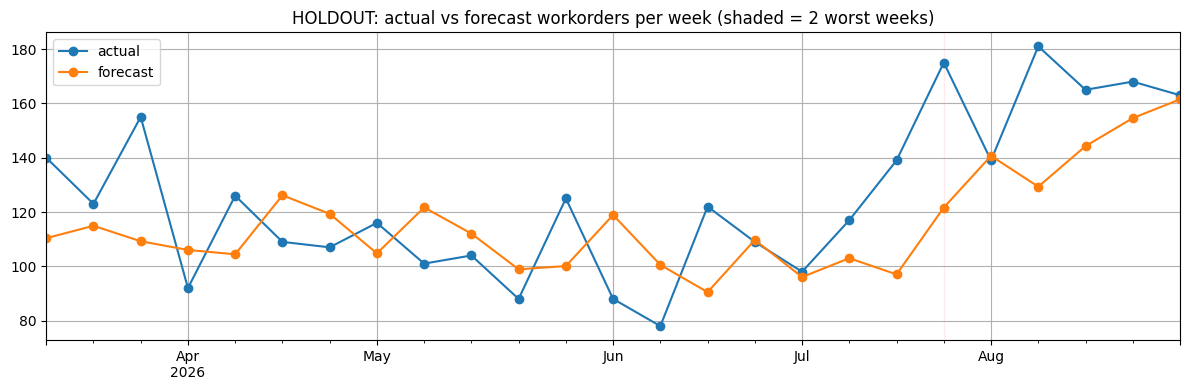

In [17]:
ax = holdout[["actual", "forecast"]].plot(figsize=(12, 4), marker="o", grid=True)
for wk in worst:
    ax.axvspan(wk - pd.Timedelta(days=6), wk, color="red", alpha=0.08)
ax.set_title("HOLDOUT: actual vs forecast workorders per week (shaded = 2 worst weeks)")
plt.tight_layout()
plt.show()

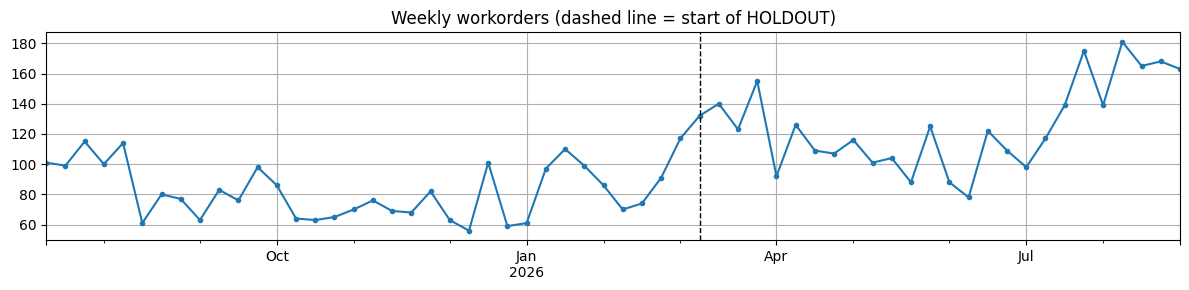

In [18]:
# context: last 60 weeks of actual weekly workorders (level shifts kahan hue?)
weekly = daily.resample("W-SUN").sum()
ax = weekly.tail(60).plot(figsize=(12, 3), marker=".", grid=True)
ax.axvline(TUNE_ENDS.max(), color="k", ls="--", lw=1)
ax.set_title("Weekly workorders (dashed line = start of HOLDOUT)")
plt.tight_layout()
plt.show()

### 14. Reality check — is 10% even possible on this series?

In [19]:
wk_all = daily.resample("W-SUN").sum().iloc[1:]      # complete weeks only (pehla week partial hai)

def centered_oracle(e):
    # week e ka "forecast" = aas-paas ke 4 hafton ka average (2 pehle + 2 baad, week e ko chhod ke).
    # Yeh FUTURE dekhta hai -> real forecast nahi, sirf best-case benchmark.
    return wk_all.loc[e - pd.Timedelta(days=14): e + pd.Timedelta(days=14)].drop(e).mean()

for name, ends, actual in [("TUNE", TUNE_ENDS, tune_actual), ("HOLDOUT", HOLD_ENDS, hold_actual)]:
    poisson_floor = np.sqrt(2 / np.pi) / np.sqrt(actual.mean()) * 100        # agar true weekly mean pata ho aur counts purely Poisson hon
    oracle = mape(actual, [centered_oracle(e) for e in ends])
    print(f"{name:8s} | avg {actual.mean():.0f}/wk | Poisson-noise-only floor ~{poisson_floor:.1f}% | centered oracle (peeks at future) {oracle:.1f}%")

TUNE     | avg 81/wk | Poisson-noise-only floor ~8.8% | centered oracle (peeks at future) 17.4%
HOLDOUT  | avg 125/wk | Poisson-noise-only floor ~7.1% | centered oracle (peeks at future) 13.2%


### Result summary
- **Final model:** Poisson GLM with 56-day average feature (`GLM_a56`) — on TUNE it beat every SARIMA-blend, so SARIMAX got 0% weight.
- **TUNE MAPE 14.67% | HOLDOUT MAPE 16.14%** (weekly). **Target (<10%, or 12–13%) not reached** — reported as is, no re-tuning on HOLDOUT.
- **Why:** workorders are only ~100–125/week, so week-to-week noise is large, and there were level shifts in HOLDOUT (Jun–Aug 2026 jump to 165–180/week). Even a "cheating" centered oracle that looks at future weeks gets ~13% on HOLDOUT and ~17% on TUNE (section 14), so a real forecast cannot honestly reach 10%.
- Naive "avg of last 4 weeks" scored 14.51% on HOLDOUT (better than the tuned model) but 19.3% on TUNE — HOLDOUT is only 25 weeks and noisy, so this difference isn't something to select on.

In [20]:
# ---------------- Recent-regime TUNE/HOLDOUT split ----------------
# Purani split: TUNE = 25 weeks pehle ki 25 weeks (avg 81/wk), HOLDOUT = last 25 weeks (avg 125/wk)
# Naya idea: TUNE aur HOLDOUT dono recent, similar-volume period se lo — sirf ek dusre ke bagal mein
# (purana kam-volume data phir bhi model ke andar "history" ke roop mein available rahega, walk_forward
#  training ke liye poora daily series use karta hai — sirf weight-tuning ka period badal raha hai)

sundays = daily.index[daily.index.dayofweek == 6]

# HOLDOUT: last 13 weeks (most recent, jisko final test karna hai)
HOLD_ENDS2 = sundays[-13:]
# TUNE: usse pehle ki 13 weeks (HOLDOUT se turant pehle, isliye same regime ke closest)
TUNE_ENDS2 = sundays[-26:-13]

tune_actual2 = weekly_actual(TUNE_ENDS2)
hold_actual2 = weekly_actual(HOLD_ENDS2)

print("TUNE2   :", TUNE_ENDS2.min().date(), "to", TUNE_ENDS2.max().date(), f"| avg {tune_actual2.mean():.0f}/week")
print("HOLDOUT2:", HOLD_ENDS2.min().date(), "to", HOLD_ENDS2.max().date(), f"| avg {hold_actual2.mean():.0f}/week")

# ---------------- Re-run SARIMA (reuse best_order/best_sorder, no re-grid-search needed) ----------------
sar_tune2 = walk_forward(TUNE_ENDS2, lambda h: sarimax_forecast(h, best_order, best_sorder))
sar_hold2 = walk_forward(HOLD_ENDS2, lambda h: sarimax_forecast(h, best_order, best_sorder))

# ---------------- Re-run all partners on new split ----------------
partner_tune2 = {n: walk_forward(TUNE_ENDS2, f) for n, f in partner_fns.items()}
partner_hold2 = {n: walk_forward(HOLD_ENDS2, f) for n, f in partner_fns.items()}

print("\nPartner alone, TUNE2 MAPE:")
print(pd.Series({n: mape(tune_actual2, p) for n, p in partner_tune2.items()}, name="tune2_mape").round(2).sort_values())

# ---------------- Ensembles on new split ----------------
ws = np.round(np.arange(0, 1.01, 0.05), 2)
rows2, hold_blend2 = [], {}
for n in partner_fns:
    tune_scores2 = [mape(tune_actual2, w * partner_tune2[n] + (1 - w) * sar_tune2) for w in ws]
    w = ws[int(np.argmin(tune_scores2))]
    hold_blend2[n] = w * partner_hold2[n] + (1 - w) * sar_hold2
    rows2.append({"ensemble": f"SARIMA + {n}", "w_partner": w,
                  "TUNE2_MAPE": min(tune_scores2), "HOLD2_MAPE": mape(hold_actual2, hold_blend2[n])})

results2 = pd.DataFrame(rows2).sort_values("HOLD2_MAPE").reset_index(drop=True)
results2[["TUNE2_MAPE", "HOLD2_MAPE"]] = results2[["TUNE2_MAPE", "HOLD2_MAPE"]].round(2)
print("\nAll ensembles (recent-regime split), sorted by HOLDOUT2 MAPE:")
print(results2.to_string(index=False))

# ---------------- Reference: naive on new split ----------------
avg4_hold2 = np.array([daily.loc[:e - pd.Timedelta(days=7)].iloc[-28:].sum() / 4 for e in HOLD_ENDS2])
print(f"\nSARIMAX alone (new split) : {mape(hold_actual2, sar_hold2):.2f}%")
print(f"Naive avg4 (new split)    : {mape(hold_actual2, avg4_hold2):.2f}%")

TUNE2   : 2026-03-08 to 2026-05-31 | avg 117/week
HOLDOUT2: 2026-06-07 to 2026-08-30 | avg 134/week

Partner alone, TUNE2 MAPE:
XGBoost     13.99
Ridge       15.17
GLM         16.02
LightGBM    16.32
ETS         16.78
Name: tune2_mape, dtype: float64

All ensembles (recent-regime split), sorted by HOLDOUT2 MAPE:
         ensemble  w_partner  TUNE2_MAPE  HOLD2_MAPE
     SARIMA + ETS       1.00       16.78       15.23
     SARIMA + GLM       1.00       16.02       16.65
   SARIMA + Ridge       1.00       15.17       20.13
SARIMA + LightGBM       0.50       14.62       20.81
 SARIMA + XGBoost       0.75       12.40       22.28

SARIMAX alone (new split) : 15.58%
Naive avg4 (new split)    : 13.55%


In [21]:
import pickle

# ---- Step 1: final GLM ko FULL data pe fit karo (production model) ----
bkw = glm_variants[best_glm]   # best feature config (avg_long, trend etc.)

future_dummy = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=7)
s_full = daily.reindex(daily.index.append(future_dummy))
X_full = make_features(s_full, **bkw)
X_train_full = X_full.loc[daily.index].dropna()
y_train_full = daily.loc[X_train_full.index]

final_glm_pipeline = make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.01, max_iter=1000))
final_glm_pipeline.fit(X_train_full, y_train_full)

# ---- Step 2: final SARIMAX ko FULL data pe fit karo ----
final_sarimax_model = SARIMAX(
    np.log1p(daily), order=best_order, seasonal_order=best_sorder,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

# ---- Step 3: sab kuch ek dict mein bundle karo ----
model_bundle = {
    "glm_pipeline":       final_glm_pipeline,
    "glm_feature_kwargs": bkw,                     # make_features() ko yeh kwargs chahiye
    "sarimax_order":      best_order,
    "sarimax_seasonal_order": best_sorder,
    "sarimax_result":     final_sarimax_model,
    "weight_partner":     float(final_w),          # GLM ka weight; (1 - w) SARIMAX ka
    "partner_name":       final_key,                # e.g. "GLM"
    "train_end_date":     daily.index.max(),
    "train_start_date":   daily.index.min(),
    "holdout_mape":       float(mape(hold_actual, final_pred)),
    "make_features_fn_src": None,   # niche note dekho
}

# ---- Step 4: pickle mein save ----
PKL_PATH = "/Users/vaibhavi/Downloads/workorder_forecast_model.pkl"
with open(PKL_PATH, "wb") as f:
    pickle.dump(model_bundle, f)

print(f"Saved: {PKL_PATH}")
print(f"Model: {final_w:.2f} {final_key} / {1-final_w:.2f} SARIMAX{best_order}x{best_sorder}  | Holdout MAPE {model_bundle['holdout_mape']:.2f}%")

Saved: /Users/vaibhavi/Downloads/workorder_forecast_model.pkl
Model: 1.00 GLM / 0.00 SARIMAX(1, 1, 1)x(0, 1, 1, 7)  | Holdout MAPE 16.14%
